# Issue 3 - Porto Dataset Profiling

This notebook profiles the Porto taxi dataset for Milestone 1 Issue 3.

- full Porto CSV files 

In [28]:
from pyspark.sql import SparkSession
from pyspark.sql.types import ArrayType, DoubleType
import pyspark.sql.functions as F
from pyspark.sql.functions import col, from_json, size, from_unixtime, to_timestamp
import math
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Make Spark Python workers use this exact interpreter and localhost on Windows
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# Stop existing session so new configs are applied
existing = SparkSession.getActiveSession()
if existing is not None:
    existing.stop()

# Lansi Spark
spark = SparkSession.builder \
    .appName("TaaSim-Profiling") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.pyspark.python", sys.executable) \
    .config("spark.pyspark.driver.python", sys.executable) \
    .getOrCreate()

sns.set_theme(style="whitegrid")

In [30]:
# Qraya dyal l-data
df = spark.read.csv("../data/downloads/porto/train.csv", header=True, inferSchema=True)

# Chouf 5 d stoura l-wala
df.show(5)

# (Optionnel) Hseb ch-hal d rows 3ndk
print(f"Total Rows: {df.count()}")

+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------+
|            TRIP_ID|CALL_TYPE|ORIGIN_CALL|ORIGIN_STAND| TAXI_ID| TIMESTAMP|DAY_TYPE|MISSING_DATA|            POLYLINE|
+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------+
|1372636858620000589|        C|       NULL|        NULL|20000589|1372636858|       A|       false|[[-8.618643,41.14...|
|1372637303620000596|        B|       NULL|           7|20000596|1372637303|       A|       false|[[-8.639847,41.15...|
|1372636951620000320|        C|       NULL|        NULL|20000320|1372636951|       A|       false|[[-8.612964,41.14...|
|1372636854620000520|        C|       NULL|        NULL|20000520|1372636854|       A|       false|[[-8.574678,41.15...|
|1372637091620000337|        C|       NULL|        NULL|20000337|1372637091|       A|       false|[[-8.645994,41.18...|
+-------------------+---------+---------

## 1) Schema Exploration

In [5]:
# Chouf l-Schema (types de données)
df.printSchema()

root
 |-- TRIP_ID: long (nullable = true)
 |-- CALL_TYPE: string (nullable = true)
 |-- ORIGIN_CALL: integer (nullable = true)
 |-- ORIGIN_STAND: integer (nullable = true)
 |-- TAXI_ID: integer (nullable = true)
 |-- TIMESTAMP: integer (nullable = true)
 |-- DAY_TYPE: string (nullable = true)
 |-- MISSING_DATA: boolean (nullable = true)
 |-- POLYLINE: string (nullable = true)



In [6]:
import pandas as pd
null_counts_row = df.agg(
    *[F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c) for c in df.columns]
).collect()[0]

unique_counts_row = df.agg(
    *[F.countDistinct(F.col(c)).alias(c) for c in df.columns]
).collect()[0]

stats = {
    "null_count": [int(null_counts_row[c]) for c in df.columns],
    "n_unique": [int(unique_counts_row[c]) for c in df.columns],
}
stats_df = pd.DataFrame(stats, index=df.columns)
print(stats_df)

              null_count  n_unique
TRIP_ID                0   1710589
CALL_TYPE              0         3
ORIGIN_CALL      1345900     57105
ORIGIN_STAND      904091        63
TAXI_ID                0       448
TIMESTAMP              0   1655366
DAY_TYPE               0         1
MISSING_DATA           0         2
POLYLINE               0   1703650


## 2) Parse POLYLINE and Build Core Metrics

In [31]:
# 1) Parse POLYLINE JSON
schema_polyline = ArrayType(ArrayType(DoubleType()))

work = df \
    .withColumn("POLYLINE_PARSED", from_json(col("POLYLINE"), schema_polyline)) \
    .withColumn("point_count", size(col("POLYLINE_PARSED"))) \
    .withColumn("duration_seconds", col("point_count") * 15)

# 2) Trip distance in km with native Spark expression (no Python UDF)
distance_expr = """
aggregate(
  sequence(1, size(POLYLINE_PARSED) - 1),
  cast(0.0 as double),
  (acc, i) -> acc + 2D * 6371D * asin(sqrt(
    pow(sin(radians(POLYLINE_PARSED[i][1] - POLYLINE_PARSED[i - 1][1]) / 2D), 2D) +
    cos(radians(POLYLINE_PARSED[i - 1][1])) * cos(radians(POLYLINE_PARSED[i][1])) *
    pow(sin(radians(POLYLINE_PARSED[i][0] - POLYLINE_PARSED[i - 1][0]) / 2D), 2D)
  ))
 )
"""

work = work \
    .withColumn(
        "trip_distance_km",
        F.when(col("point_count") < 2, F.lit(0.0)).otherwise(F.expr(distance_expr))
    ) \
    .withColumn("event_dt", to_timestamp(from_unixtime(col("TIMESTAMP"))))

# N-shoufou N-natija
work.select("TRIP_ID","POLYLINE_PARSED","point_count", "duration_seconds", "trip_distance_km", "event_dt").show(3)

+-------------------+--------------------+-----------+----------------+------------------+-------------------+
|            TRIP_ID|     POLYLINE_PARSED|point_count|duration_seconds|  trip_distance_km|           event_dt|
+-------------------+--------------------+-----------+----------------+------------------+-------------------+
|1372636858620000589|[[-8.618643, 41.1...|         23|             345|2.6510484137007277|2013-07-01 01:00:58|
|1372637303620000596|[[-8.639847, 41.1...|         19|             285|3.4562685861781524|2013-07-01 01:08:23|
|1372636951620000320|[[-8.612964, 41.1...|         65|             975| 17.63044867493785|2013-07-01 01:02:31|
+-------------------+--------------------+-----------+----------------+------------------+-------------------+
only showing top 3 rows



## What does this code do?
- Cleans and transforms GPS data
- Converts raw text into usable numerical data

## Main steps
- **parse_polyline / from_json**
  - Convert GPS text (polyline) → array of coordinates

- **duration_seconds**
  - Count number of GPS points
  - Multiply by 15 → get trip duration (seconds)

- **trip_distance_km (Haversine)**
  - Compute distance between GPS points (Earth is round)
  - Sum all distances → total trip distance (km)

## Why is it important?
- ML models cannot understand raw GPS text
- They need numerical features like:
  - Distance (km)
  - Duration (seconds/minutes)

## How you will use it (TaaSim)
- **Average Speed**
  - `distance / duration`

- **ETA (Estimated Time)**
  - Based on average speed

- **Machine Learning**
  - Understand trip patterns (short vs long trips)

- **Dynamic Pricing**
  - Use distance + time to estimate trip price

## 3) Statistical Profiling

In [ ]:
import pyspark.sql.functions as F

# Kan-7esbou l-majmou3 dyal r-re7lat kamlin bash n-qesmo 3lih
total_trips = df.count()

# ---------------------------------------------------------
# 1. MISSING_DATA true rate 
# ---------------------------------------------------------
missing_data_count = df.filter(F.lower(F.col("MISSING_DATA")) == "true").count()
missing_rate = (missing_data_count / total_trips) * 100

print(f"MISSING_DATA true rate: {missing_rate:.2f}%")

# ---------------------------------------------------------
# 2. CALL_TYPE distribution (%) 
# ---------------------------------------------------------
print("\nCALL_TYPE distribution (%):")
call_type_pct = df.groupBy("CALL_TYPE") \
    .count() \
    .withColumn("percentage", F.round((F.col("count") / total_trips) * 100, 2)) \
    .orderBy(F.desc("percentage"))

call_type_pct.show()

# ---------------------------------------------------------
# 3. Trips per Taxi Summary 
# ---------------------------------------------------------
print("\nTrips per taxi summary:")
# N-jme3ou sh-hal mn re7la dar koul taxi
trips_per_taxi = df.groupBy("TAXI_ID") \
    .agg(F.count("TRIP_ID").alias("total_trips"))

# N-khrjou l-i7sa2iyat (mean, stddev, min, max)
trips_per_taxi.describe("total_trips").show()

MISSING_DATA true rate: 0.00%

CALL_TYPE distribution (%):
+---------+------+----------+
|CALL_TYPE| count|percentage|
+---------+------+----------+
|        B|817881|     47.81|
|        C|528019|     30.87|
|        A|364770|     21.32|
+---------+------+----------+


Trips per taxi summary:
+-------+------------------+
|summary|       total_trips|
+-------+------------------+
|  count|               448|
|   mean|3818.4598214285716|
| stddev|1644.0211732422645|
|    min|                 1|
|    max|             10746|
+-------+------------------+



## What is this work?
- Called **Statistical Profiling**
- Used to analyze and understand the dataset

## What does it do?

- **MISSING_DATA (true rate)**
  - Count rows where `MISSING_DATA = True`
  - Compute percentage of missing/broken GPS data

- **CALL_TYPE distribution**
  - Group trips by type (A, B, C)
  - Calculate percentage of each type

- **Trips per taxi summary**
  - Count trips for each `TAXI_ID`
  - Compute:
    - Mean (average trips)
    - Min (least trips)
    - Max (most trips)

## Why is it useful in TaaSim?

- **Data Cleaning (ETL - Week 5)**
  - Know how much data will be removed (`MISSING_DATA = True`)
  - Helps understand data quality before processing

- **Understanding Call Types**
  - A = App / Dispatch  
  - B = Taxi Stand  
  - C = Street Hail  
  - Helps compare with real taxi behavior (like Casablanca)

- **Driver Analysis (Bonus)**
  - Shows if work is equally distributed between drivers
  - Useful for:
    - Driver earnings tracking
    - Utilization rate dashboard

## Goal
- Better understanding of data
- Prepare clean and reliable input for analysis & ML

## 4) Temporal Analysis

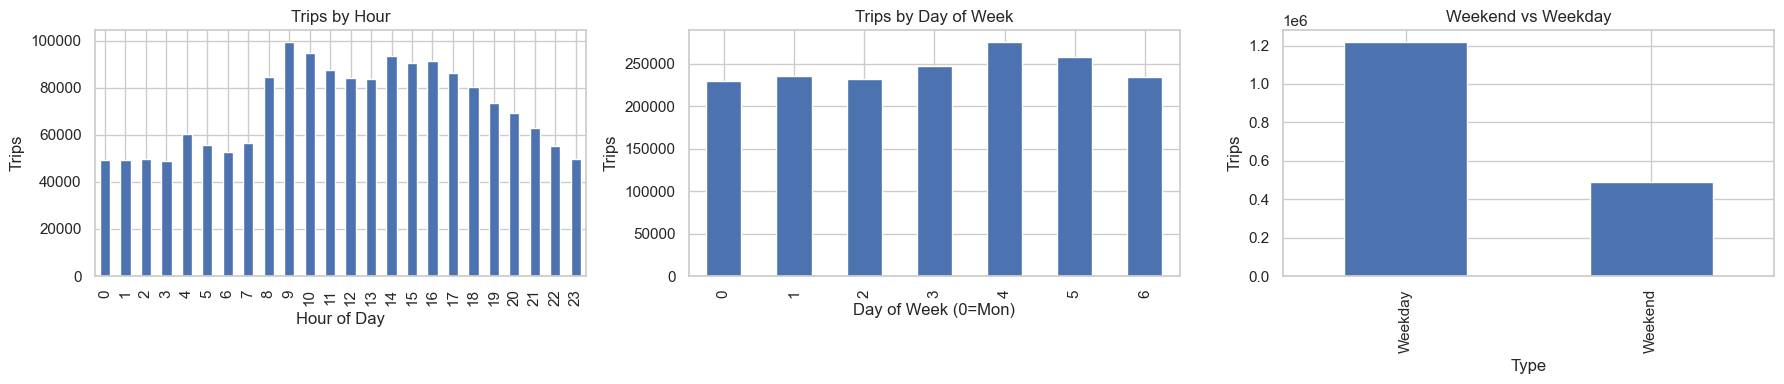

In [21]:
work = work \
    .withColumn('hour', F.hour('event_dt')) \
    .withColumn('dow', ((F.dayofweek('event_dt') + 5) % 7)) \
    .withColumn('is_weekend', F.col('dow').isin([5, 6]))

hourly_df = work.groupBy('hour').count().orderBy('hour')
dow_counts_df = work.groupBy('dow').count().orderBy('dow')
weekend_split_df = work.groupBy('is_weekend').count().orderBy('is_weekend')

hourly = hourly_df.toPandas().set_index('hour')['count']
dow_counts = dow_counts_df.toPandas().set_index('dow')['count']
weekend_split = weekend_split_df.toPandas().set_index('is_weekend')['count']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hourly.plot(kind='bar', ax=axes[0], title='Trips by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Trips')

dow_counts.plot(kind='bar', ax=axes[1], title='Trips by Day of Week')
axes[1].set_xlabel('Day of Week (0=Mon)')
axes[1].set_ylabel('Trips')

weekend_split.rename(index={False: 'Weekday', True: 'Weekend'}).plot(kind='bar', ax=axes[2], title='Weekend vs Weekday')
axes[2].set_xlabel('Type')
axes[2].set_ylabel('Trips')

plt.tight_layout()

## 4.1) Temporal Deep Dive (Issue checklist extras)
- Active taxis per hour
- Friday 12:00-14:59 reduced-rate check
- Peak windows: 07-09 and 17-19

Active taxis per hour (sample):
hour
0    342
1    341
2    339
3    353
4    375
5    398
6    415
7    432
8    436
9    440
Name: active_taxis, dtype: int64

Friday trips at 12-14h: 43953 of 275416 (15.96%)
All-data 12-14h share: 15.28%
Morning peak (07-09) trips: 240687
Evening peak (17-19) trips: 240669


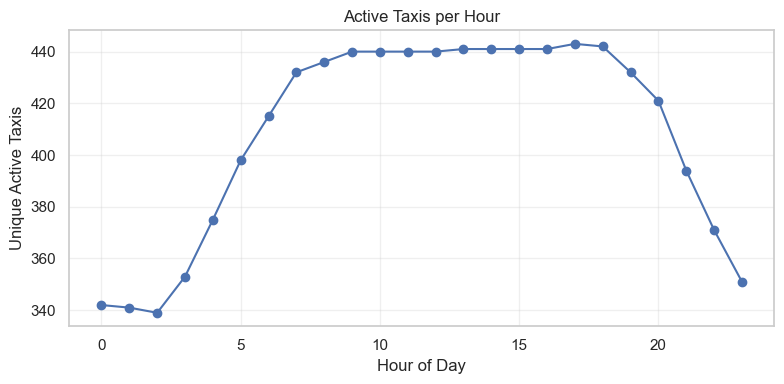

In [22]:
active_taxis_per_hour_df = work.groupBy('hour').agg(F.countDistinct('TAXI_ID').alias('active_taxis')).orderBy('hour')
active_taxis_per_hour = active_taxis_per_hour_df.toPandas().set_index('hour')['active_taxis']

friday = work.filter(F.col('dow') == 4)
friday_total = friday.count()
friday_12_14 = friday.filter(F.col('hour').between(12, 14))
friday_12_14_count = friday_12_14.count()
weekday_12_14_count = work.filter(F.col('hour').between(12, 14)).count()

friday_12_14_rate = float(friday_12_14_count / friday_total * 100) if friday_total else 0.0
weekday_12_14_rate = float(weekday_12_14_count / work.count() * 100) if work.count() else 0.0

morning_peak_trips = int(work.filter(F.col('hour').between(7, 9)).count())
evening_peak_trips = int(work.filter(F.col('hour').between(17, 19)).count())

print('Active taxis per hour (sample):')
print(active_taxis_per_hour.head(10))
print(f"\nFriday trips at 12-14h: {friday_12_14_count} of {friday_total} ({friday_12_14_rate:.2f}%)")
print(f"All-data 12-14h share: {weekday_12_14_rate:.2f}%")
print(f"Morning peak (07-09) trips: {morning_peak_trips}")
print(f"Evening peak (17-19) trips: {evening_peak_trips}")

fig, ax = plt.subplots(figsize=(8, 4))
active_taxis_per_hour.plot(kind='line', marker='o', ax=ax)
ax.set_title('Active Taxis per Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Unique Active Taxis')
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 5) Spatial Analysis (Start/End Points)

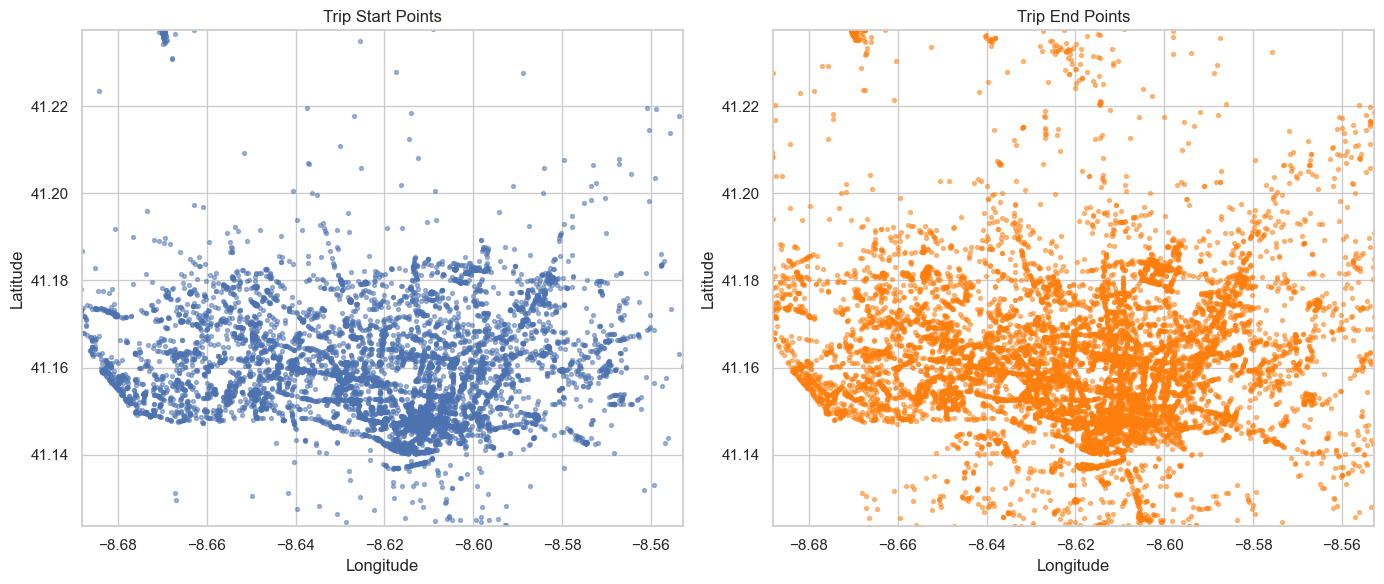

In [36]:
work = work \
    .withColumn('start_lon', F.when(F.col('point_count') > 0, F.expr('POLYLINE_PARSED[0][0]'))) \
    .withColumn('start_lat', F.when(F.col('point_count') > 0, F.expr('POLYLINE_PARSED[0][1]'))) \
    .withColumn('end_lon', F.when(F.col('point_count') > 0, F.expr('POLYLINE_PARSED[point_count - 1][0]'))) \
    .withColumn('end_lat', F.when(F.col('point_count') > 0, F.expr('POLYLINE_PARSED[point_count - 1][1]')))

scatter_sample = work.select('start_lon', 'start_lat', 'end_lon', 'end_lat').dropna().sample(False, 0.01, seed=42).limit(20000).toPandas()

lon_min = float(min(scatter_sample['start_lon'].quantile(0.02), scatter_sample['end_lon'].quantile(0.02)))
lon_max = float(max(scatter_sample['start_lon'].quantile(0.98), scatter_sample['end_lon'].quantile(0.98)))
lat_min = float(min(scatter_sample['start_lat'].quantile(0.02), scatter_sample['end_lat'].quantile(0.02)))
lat_max = float(max(scatter_sample['start_lat'].quantile(0.98), scatter_sample['end_lat'].quantile(0.98)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(scatter_sample['start_lon'], scatter_sample['start_lat'], s=8, alpha=0.5)
axes[0].set_xlim(lon_min, lon_max)
axes[0].set_ylim(lat_min, lat_max)
axes[0].set_title('Trip Start Points')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(scatter_sample['end_lon'], scatter_sample['end_lat'], s=8, alpha=0.5, color='tab:orange')
axes[1].set_xlim(lon_min, lon_max)
axes[1].set_ylim(lat_min, lat_max)
axes[1].set_title('Trip End Points')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()

## 5.1) Most Popular Origin/Destination Areas
Using a simple spatial binning approach (rounded lat/lon) as proxy zones for top origin and destination hotspots.

Top 10 origin areas (rounded lat,lon bins):
origin_zone
41.15,-8.61    317407
41.14,-8.61    108601
41.15,-8.62    104272
41.15,-8.59    101752
41.16,-8.63     96116
41.18,-8.6      65698
41.16,-8.6      59802
41.15,-8.63     52797
41.16,-8.64     50773
41.15,-8.65     46709
Name: count, dtype: int64

Top 10 destination areas (rounded lat,lon bins):
destination_zone
41.15,-8.61    173415
41.15,-8.62     88520
41.16,-8.63     66726
41.24,-8.67     61917
41.14,-8.61     60712
41.15,-8.6      55473
41.16,-8.64     54427
41.16,-8.6      53955
41.15,-8.59     53781
41.16,-8.61     53597
Name: count, dtype: int64


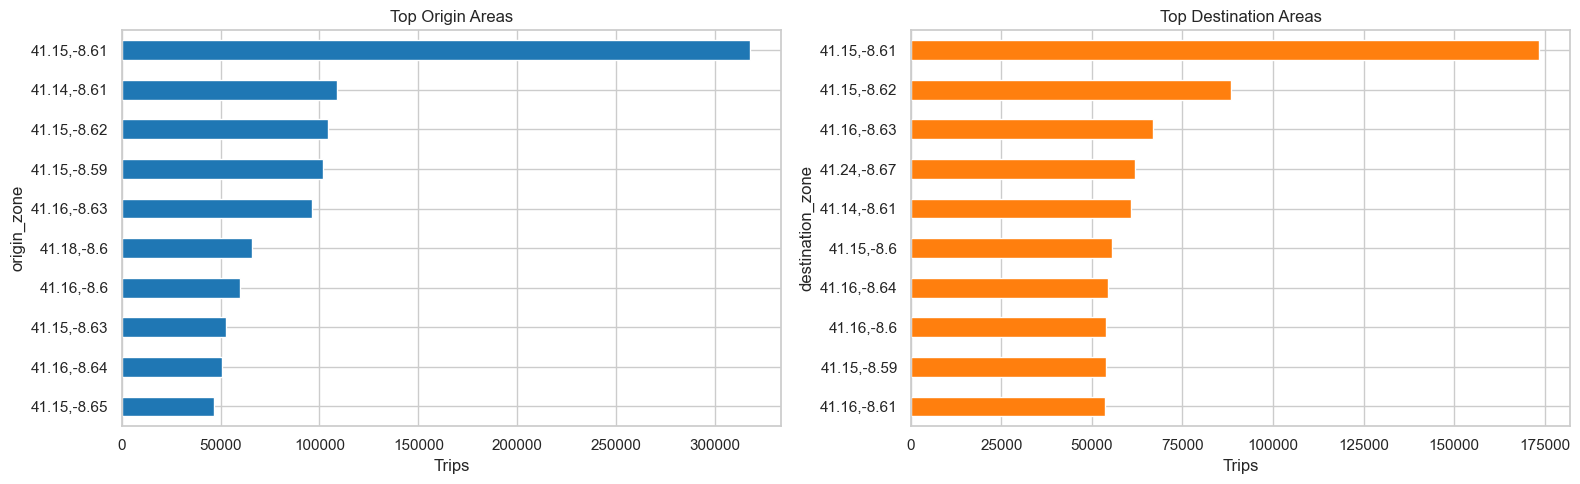

In [24]:
zone_precision = 2

work = work \
    .withColumn('origin_zone', F.concat(F.round('start_lat', zone_precision).cast('string'), F.lit(','), F.round('start_lon', zone_precision).cast('string'))) \
    .withColumn('destination_zone', F.concat(F.round('end_lat', zone_precision).cast('string'), F.lit(','), F.round('end_lon', zone_precision).cast('string')))

top_origin_areas_df = work.groupBy('origin_zone').count().orderBy(F.desc('count')).limit(10)
top_destination_areas_df = work.groupBy('destination_zone').count().orderBy(F.desc('count')).limit(10)

top_origin_areas = top_origin_areas_df.toPandas().set_index('origin_zone')['count']
top_destination_areas = top_destination_areas_df.toPandas().set_index('destination_zone')['count']

print('Top 10 origin areas (rounded lat,lon bins):')
print(top_origin_areas)
print('\nTop 10 destination areas (rounded lat,lon bins):')
print(top_destination_areas)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_origin_areas.sort_values().plot(kind='barh', ax=axes[0], color='tab:blue')
axes[0].set_title('Top Origin Areas')
axes[0].set_xlabel('Trips')

top_destination_areas.sort_values().plot(kind='barh', ax=axes[1], color='tab:orange')
axes[1].set_title('Top Destination Areas')
axes[1].set_xlabel('Trips')

plt.tight_layout()

## 6) Core Visualizations Required by Issue 3

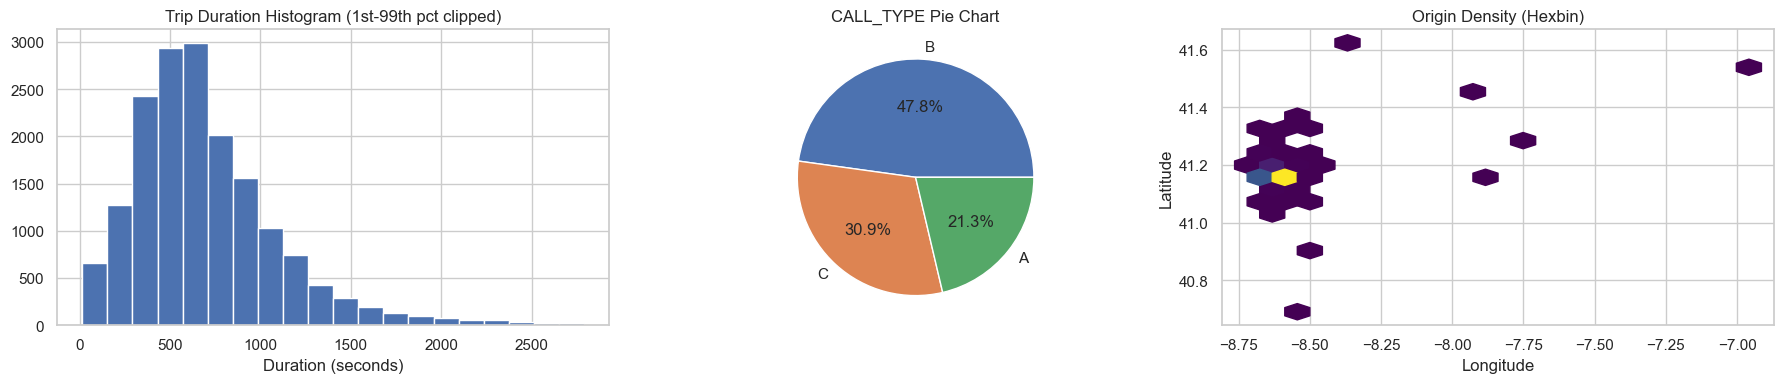

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

duration_bounds = work.agg(F.expr('percentile_approx(duration_seconds, array(0.01, 0.99), 1000) as bounds')).first()['bounds']
duration_low, duration_high = float(duration_bounds[0]), float(duration_bounds[1])
duration_sample = work.select('duration_seconds').sample(False, 0.01, seed=42).limit(20000).toPandas()['duration_seconds']
duration_sample = duration_sample[(duration_sample >= duration_low) & (duration_sample <= duration_high)]
axes[0].hist(duration_sample, bins=20, range=(duration_low, duration_high))
axes[0].set_title('Trip Duration Histogram (1st-99th pct clipped)')
axes[0].set_xlabel('Duration (seconds)')

call_type_counts = work.groupBy('CALL_TYPE').count().orderBy(F.desc('count')).toPandas().set_index('CALL_TYPE')['count']
axes[1].pie(call_type_counts.values, labels=call_type_counts.index, autopct='%1.1f%%')
axes[1].set_title('CALL_TYPE Pie Chart')

origin_sample = work.select('start_lon', 'start_lat').dropna().sample(False, 0.01, seed=42).limit(20000).toPandas()
axes[2].hexbin(origin_sample['start_lon'], origin_sample['start_lat'], gridsize=20, cmap='viridis', mincnt=1)
axes[2].set_title('Origin Density (Hexbin)')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')

plt.tight_layout()

## 7) Key Findings (Auto-generated Summary)

In [35]:
summary = {
    'rows': int(work.count()),
    'unique_taxis': int(work.select('TAXI_ID').distinct().count()),
    'avg_duration_seconds': float(work.agg(F.avg('duration_seconds').alias('avg')).first()['avg']),
    'avg_distance_km': float(work.agg(F.avg('trip_distance_km').alias('avg')).first()['avg']),
    'missing_data_pct': float(missing_rate),
    'peak_hour': int(hourly.idxmax()) if len(hourly) else None,
    'top_call_type': str(call_type_counts.idxmax()) if len(call_type_counts) else None,
    'morning_peak_07_09_trips': int(morning_peak_trips),
    'evening_peak_17_19_trips': int(evening_peak_trips),
    'friday_12_14_share_pct': float(friday_12_14_rate),
    'all_data_12_14_share_pct': float(weekday_12_14_rate),
    'top_origin_area': str(top_origin_areas.index[0]) if len(top_origin_areas) else None,
    'top_destination_area': str(top_destination_areas.index[0]) if len(top_destination_areas) else None,
}

for k, v in summary.items():
    print(f'{k}: {v}')

rows: 1710670
unique_taxis: 448
avg_duration_seconds: 731.3747186774773
avg_distance_km: 5.505667286512912
missing_data_pct: 0.0005845662810477765
peak_hour: 9
top_call_type: B
morning_peak_07_09_trips: 240687
evening_peak_17_19_trips: 240669
friday_12_14_share_pct: 15.95876782757719
all_data_12_14_share_pct: 15.277873581696062
top_origin_area: 41.15,-8.61
top_destination_area: 41.15,-8.61


### Findings Notes
- Demand and activity windows are now explicitly measured, including active taxis per hour.
- Friday 12:00-14:59 behavior is explicitly computed for comparison with overall 12-14h share.
- Most popular origin and destination areas are reported using rounded lat/lon spatial bins.
- On quick-mode sample data these patterns are directional; rerun on full dataset for final report values.

### Notes
- If you are on quick mode sample data, trends are illustrative only.
- Re-run this notebook after full dataset ingestion for final analysis outputs.

In [2]:
import csv
import os

# 16 Arrondissements of Casablanca with realistic geographic adjacency
arrondissements = [
    {"zone_id": 1, "zone_name": "Anfa", "zone_type": "commercial", "population_density": 8000, "centroid_lat": 33.593, "centroid_lon": -7.632},
    {"zone_id": 2, "zone_name": "Maarif", "zone_type": "commercial", "population_density": 15000, "centroid_lat": 33.585, "centroid_lon": -7.640},
    {"zone_id": 3, "zone_name": "Sidi Belyout", "zone_type": "commercial", "population_density": 9500, "centroid_lat": 33.592, "centroid_lon": -7.618},
    {"zone_id": 4, "zone_name": "El Fida", "zone_type": "residential", "population_density": 35000, "centroid_lat": 33.570, "centroid_lon": -7.608},
    {"zone_id": 5, "zone_name": "Mers Sultan", "zone_type": "residential", "population_density": 30000, "centroid_lat": 33.575, "centroid_lon": -7.612},
    {"zone_id": 6, "zone_name": "Ain Sebaa", "zone_type": "industrial", "population_density": 10000, "centroid_lat": 33.606, "centroid_lon": -7.540},
    {"zone_id": 7, "zone_name": "Hay Mohammadi", "zone_type": "residential", "population_density": 40000, "centroid_lat": 33.596, "centroid_lon": -7.570},
    {"zone_id": 8, "zone_name": "Roches Noires", "zone_type": "industrial", "population_density": 12000, "centroid_lat": 33.600, "centroid_lon": -7.585},
    {"zone_id": 9, "zone_name": "Hay Hassani", "zone_type": "residential", "population_density": 22000, "centroid_lat": 33.560, "centroid_lon": -7.675},
    {"zone_id": 10, "zone_name": "Ain Chock", "zone_type": "transit_hub", "population_density": 18000, "centroid_lat": 33.542, "centroid_lon": -7.614},
    {"zone_id": 11, "zone_name": "Sidi Bernoussi", "zone_type": "industrial", "population_density": 16000, "centroid_lat": 33.590, "centroid_lon": -7.490},
    {"zone_id": 12, "zone_name": "Sidi Moumen", "zone_type": "residential", "population_density": 25000, "centroid_lat": 33.575, "centroid_lon": -7.525},
    {"zone_id": 13, "zone_name": "Ben M'Sick", "zone_type": "residential", "population_density": 38000, "centroid_lat": 33.555, "centroid_lon": -7.580},
    {"zone_id": 14, "zone_name": "Sbata", "zone_type": "residential", "population_density": 34000, "centroid_lat": 33.550, "centroid_lon": -7.590},
    {"zone_id": 15, "zone_name": "Moulay Rachid", "zone_type": "residential", "population_density": 28000, "centroid_lat": 33.540, "centroid_lon": -7.550},
    {"zone_id": 16, "zone_name": "Sidi Othmane", "zone_type": "residential", "population_density": 26000, "centroid_lat": 33.545, "centroid_lon": -7.570},
]

# Geographic adjacency based on actual Casablanca arrondissement borders
# Each zone's neighbors determined by geographic proximity of centroids
ADJACENCY = {
    1: [2, 3, 9],           # Anfa: coastal west, neighbors Maarif, Sidi Belyout, Hay Hassani
    2: [1, 5, 9, 14],       # Maarif: borders Anfa, Mers Sultan, Hay Hassani, Sbata
    3: [1, 5, 7, 8],        # Sidi Belyout: downtown, near Mers Sultan, Hay Mohammadi, Roches Noires
    4: [5, 13, 14],         # El Fida: inner city, near Mers Sultan, Ben M'Sick, Sbata
    5: [3, 4, 8, 13],       # Mers Sultan: central, near Sidi Belyout, El Fida, Roches Noires, Ben M'Sick
    6: [7, 11, 12],         # Ain Sebaa: NE industrial, near Hay Mohammadi, Sidi Bernoussi, Sidi Moumen
    7: [3, 6, 8, 12],       # Hay Mohammadi: east-central, near Sidi Belyout, Ain Sebaa, Roches Noires, Sidi Moumen
    8: [3, 5, 7, 13],       # Roches Noires: port area, near Sidi Belyout, Mers Sultan, Hay Mohammadi, Ben M'Sick
    9: [1, 2, 10, 14],      # Hay Hassani: SW, near Anfa, Maarif, Ain Chock, Sbata
    10: [9, 14, 15, 16],    # Ain Chock: south, near Hay Hassani, Sbata, Moulay Rachid, Sidi Othmane
    11: [6, 12],            # Sidi Bernoussi: far NE, near Ain Sebaa, Sidi Moumen
    12: [6, 7, 11, 15, 16], # Sidi Moumen: east, near Ain Sebaa, Hay Mohammadi, Sidi Bernoussi, Moulay Rachid, Sidi Othmane
    13: [4, 5, 8, 14, 16],  # Ben M'Sick: inner south, near El Fida, Mers Sultan, Roches Noires, Sbata, Sidi Othmane
    14: [2, 4, 9, 10, 13],  # Sbata: south-central, near Maarif, El Fida, Hay Hassani, Ain Chock, Ben M'Sick
    15: [10, 12, 16],       # Moulay Rachid: SE, near Ain Chock, Sidi Moumen, Sidi Othmane
    16: [10, 12, 13, 15],   # Sidi Othmane: south-east, near Ain Chock, Sidi Moumen, Ben M'Sick, Moulay Rachid
}

for zone in arrondissements:
    zone["adjacency_list"] = str(ADJACENCY[zone["zone_id"]])

def main():
    base_dir = os.getcwd()
    data_dir = os.path.join(base_dir, "data")
    if not os.path.isdir(data_dir):
        data_dir = os.path.join(base_dir, "..", "data")
    output_path = os.path.abspath(os.path.join(data_dir, "zone_mapping.csv"))

    # Ensure directory exists
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    with open(output_path, 'w', newline='', encoding='utf-8') as f:
        fieldnames = ["zone_id", "zone_name", "zone_type", "population_density", "centroid_lat", "centroid_lon", "adjacency_list"]
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        writer.writeheader()
        for zone in arrondissements:
            writer.writerow(zone)

    print(f"Successfully generated {output_path} with {len(arrondissements)} zones.")

if __name__ == "__main__":
    main()


Successfully generated c:\Users\dell\Desktop\big data project\TaaSim-Project\data\zone_mapping.csv with 16 zones.


## 8) Milestone 1 Map Preview (Porto to Casablanca Remap)
This section samples Porto trips, remaps coordinates to Casablanca, and renders an interactive OpenStreetMap preview.

In [3]:
import csv
import json
import os
import subprocess
import sys

try:
    import folium
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "folium", "-q"])
    import folium

# Same linear transform used in issue4 remapper
PORTO_MIN_LAT = 41.13
PORTO_MIN_LON = -8.68
PORTO_LAT_RANGE = 41.19 - 41.13
PORTO_LON_RANGE = -8.55 - (-8.68)

CASA_MIN_LAT = 33.48
CASA_MIN_LON = -7.68
CASA_LAT_RANGE = 33.63 - 33.48
CASA_LON_RANGE = -7.53 - (-7.68)

SCALE_LAT = CASA_LAT_RANGE / PORTO_LAT_RANGE
SCALE_LON = CASA_LON_RANGE / PORTO_LON_RANGE

def transform_point(lon, lat):
    new_lat = CASA_MIN_LAT + (lat - PORTO_MIN_LAT) * SCALE_LAT
    new_lon = CASA_MIN_LON + (lon - PORTO_MIN_LON) * SCALE_LON
    return new_lon, new_lat

# Resolve CSV path from either notebook folder or project root
csv_path = "../data/downloads/porto/train.csv"
if not os.path.exists(csv_path):
    csv_path = "data/downloads/porto/train.csv"

trajectories = []
max_trips = 250

with open(csv_path, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        polyline_str = row.get("POLYLINE", "[]")
        try:
            points = json.loads(polyline_str)
        except json.JSONDecodeError:
            continue

        if len(points) < 2:
            continue

        # Remap full trajectory and convert to folium order: [lat, lon]
        remapped_line = []
        for lon, lat in points:
            c_lon, c_lat = transform_point(lon, lat)
            remapped_line.append([c_lat, c_lon])

        trajectories.append(remapped_line)

        if len(trajectories) >= max_trips:
            break

m = folium.Map(location=[33.57, -7.61], zoom_start=11, tiles="OpenStreetMap")

for line in trajectories:
    folium.PolyLine(
        locations=line,
        color="#1f77b4",
        weight=2,
        opacity=0.2,
    ).add_to(m)

legend_html = """
<div style='position: fixed; bottom: 30px; left: 30px; width: 230px;
            background: white; z-index:9999; padding: 8px; border: 1px solid #999;'>
  <b>Trajectory Preview Legend</b><br>
  <span style='color:#1f77b4;'>━</span> Remapped trip trajectories<br>
  Sample size: 250 trips
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

map_output = "../data/casablanca_remap_preview.html"
if not os.path.isdir(os.path.dirname(map_output)):
    map_output = "data/casablanca_remap_preview.html"
m.save(map_output)

print(f"Map saved to: {os.path.abspath(map_output)}")
print(f"Trajectories rendered: {len(trajectories)}")
m

Map saved to: c:\Users\dell\Desktop\big data project\TaaSim-Project\data\casablanca_remap_preview.html
Trajectories rendered: 250


## 9) Live Streaming Simulation (Trip + GPS + Anomaly)
This section runs the three scripts together, consumes live Kafka events, and visualizes the simulation on an interactive map.
- Blue lines: GPS trajectories from `vehicle_gps_producer.py`
- Red circles: trip origins from `trip_request_producer.py`
- Gold circles: anomaly trip origins injected by `event_injector.py`

In [7]:
import os
import csv
import json
import time
import uuid
import subprocess
import sys
from collections import defaultdict

from IPython.display import display
from kafka import KafkaConsumer

try:
    import ipywidgets as widgets
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ipywidgets", "-q"])
    import ipywidgets as widgets

try:
    from ipyleaflet import Map, Polyline, CircleMarker, LayerGroup, LayersControl, WidgetControl
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ipyleaflet", "-q"])
    from ipyleaflet import Map, Polyline, CircleMarker, LayerGroup, LayersControl, WidgetControl

import random

# ------------------------------------------------------------------
# USER CONTROLS (edit these values, then run cell)
# ------------------------------------------------------------------
BOOTSTRAP = "localhost:9092"
SIM_DURATION_S = 25
TRIP_RATE = 2
GPS_MAX_TRIPS = 2
GPS_SPEED = 35

ANOMALY_MODE = "demand_spike"  # one of: none, demand_spike, rain_event, gps_blackout
ANOMALY_DELAY_S = 6
MAX_TRIP_LINES = 700  # cap line count to keep map responsive

# demand_spike settings (RANDOMIZE for variety)
SPIKE_ZONE = random.randint(1, 16)    # Random zone each run
SPIKE_FACTOR = random.uniform(1.5, 3.0)  # Random multiplier (1.5-3.0)
SPIKE_DURATION_S = random.randint(5, 10)  # Random duration (5-10s)

# rain_event settings
RAIN_FACTOR = 1.4
RAIN_DURATION_S = 8

# gps_blackout settings
BLACKOUT_TAXIS = "20000589,20000596"
BLACKOUT_DURATION_S = 8

# map styling
COLOR_GPS = "#1f77b4"
COLOR_TRIP = "red"
COLOR_TRIP_LINE = "#e63946"
COLOR_ANOMALY = "gold"

TRIPS_TOPIC = "raw.trips"
GPS_TOPIC = "raw.gps"

print(f"Configuration for this run:")
print(f"  SPIKE_ZONE: {SPIKE_ZONE}")
print(f"  SPIKE_FACTOR: {SPIKE_FACTOR:.2f}x")
print(f"  SPIKE_DURATION_S: {SPIKE_DURATION_S}s")
print()

# ------------------------------------------------------------------
# Resolve project paths robustly
# ------------------------------------------------------------------
project_root = os.getcwd()
if not os.path.isdir(os.path.join(project_root, "scripts")):
    project_root = os.path.abspath(os.path.join(project_root, ".."))

scripts_dir = os.path.join(project_root, "scripts")
data_dir = os.path.join(project_root, "data")

trip_script = os.path.join(scripts_dir, "trip_request_producer.py")
gps_script = os.path.join(scripts_dir, "vehicle_gps_producer.py")
inject_script = os.path.join(scripts_dir, "event_injector.py")
zone_path = os.path.join(data_dir, "zone_mapping.csv")

# ------------------------------------------------------------------
# Load zone centroids for plotting trip origins
# ------------------------------------------------------------------
zone_centroids = {}
with open(zone_path, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        zone_id = int(row["zone_id"])
        zone_centroids[zone_id] = (float(row["centroid_lat"]), float(row["centroid_lon"]))

# ------------------------------------------------------------------
# Build fixed map once (layers updated in place)
# ------------------------------------------------------------------
m = Map(center=(33.57, -7.61), zoom=11)
m.layout.height = "650px"

gps_group = LayerGroup(layers=[])
trip_group = LayerGroup(layers=[])
trip_line_group = LayerGroup(layers=[])
anomaly_group = LayerGroup(layers=[])

m.add_layer(gps_group)
m.add_layer(trip_line_group)
m.add_layer(trip_group)
m.add_layer(anomaly_group)
m.add_control(LayersControl(position="topright"))

legend_html = widgets.HTML(value="")
legend_control = WidgetControl(widget=legend_html, position="bottomleft")
m.add_control(legend_control)
display(m)

# ------------------------------------------------------------------
# Consumers (latest-only for this run)
# ------------------------------------------------------------------
trip_consumer = KafkaConsumer(
    TRIPS_TOPIC,
    bootstrap_servers=BOOTSTRAP,
    auto_offset_reset="latest",
    group_id=f"nb-sim-trips-{uuid.uuid4()}",
    enable_auto_commit=False,
    value_deserializer=lambda msg: json.loads(msg.decode("utf-8")),
)

gps_consumer = KafkaConsumer(
    GPS_TOPIC,
    bootstrap_servers=BOOTSTRAP,
    auto_offset_reset="latest",
    group_id=f"nb-sim-gps-{uuid.uuid4()}",
    enable_auto_commit=False,
    value_deserializer=lambda msg: json.loads(msg.decode("utf-8")),
)

trip_consumer.poll(timeout_ms=500)
gps_consumer.poll(timeout_ms=500)

# ------------------------------------------------------------------
# Producer commands
# ------------------------------------------------------------------
trip_cmd = [
    sys.executable, trip_script,
    "--rate", str(TRIP_RATE),
    "--duration", str(SIM_DURATION_S),
    "--kafka", BOOTSTRAP,
    "--topic", TRIPS_TOPIC,
]

gps_cmd = [
    sys.executable, gps_script,
    "--max-trips", str(GPS_MAX_TRIPS),
    "--speed", str(GPS_SPEED),
    "--kafka", BOOTSTRAP,
    "--topic", GPS_TOPIC,
]

def build_inject_cmd(mode: str):
    if mode == "none":
        return None
    if mode == "demand_spike":
        return [
            sys.executable, inject_script,
            "--kafka", BOOTSTRAP,
            "--base-rate", str(TRIP_RATE),
            "demand_spike",
            "--zone", str(SPIKE_ZONE),
            "--factor", str(SPIKE_FACTOR),
            "--duration", str(SPIKE_DURATION_S),
            "--topic", TRIPS_TOPIC,
        ]
    if mode == "rain_event":
        return [
            sys.executable, inject_script,
            "--kafka", BOOTSTRAP,
            "--base-rate", str(TRIP_RATE),
            "rain_event",
            "--factor", str(RAIN_FACTOR),
            "--duration", str(RAIN_DURATION_S),
            "--topic", TRIPS_TOPIC,
        ]
    if mode == "gps_blackout":
        return [
            sys.executable, inject_script,
            "--kafka", BOOTSTRAP,
            "--base-rate", str(TRIP_RATE),
            "gps_blackout",
            "--taxis", BLACKOUT_TAXIS,
            "--duration", str(BLACKOUT_DURATION_S),
            "--topic", GPS_TOPIC,
        ]
    raise ValueError(f"Unsupported ANOMALY_MODE: {mode}")

inject_cmd = build_inject_cmd(ANOMALY_MODE)

print("Starting simulation processes...")
trip_proc = subprocess.Popen(trip_cmd, cwd=project_root, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
gps_proc = subprocess.Popen(gps_cmd, cwd=project_root, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# ------------------------------------------------------------------
# Stream loop: update layers only (map stays fixed)
# ------------------------------------------------------------------
gps_points_by_trip = defaultdict(list)
gps_line_by_trip = {}

trip_events = []
gps_events = []
trip_lines_drawn = 0

normal_trip_count = 0
anomaly_trip_count = 0
inject_started = False
start_ts = time.time()

while time.time() - start_ts < SIM_DURATION_S + 4:
    elapsed = time.time() - start_ts

    if inject_cmd is not None and not inject_started and elapsed > ANOMALY_DELAY_S:
        print(f"Starting anomaly injector ({ANOMALY_MODE})...")
        subprocess.Popen(inject_cmd, cwd=project_root, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        inject_started = True

    trip_batch = trip_consumer.poll(timeout_ms=250, max_records=300)
    for records in trip_batch.values():
        for rec in records:
            e = rec.value
            trip_events.append(e)

            origin_zone = e.get("origin_zone")
            destination_zone = e.get("destination_zone")
            if origin_zone not in zone_centroids:
                continue
            lat, lon = zone_centroids[origin_zone]

            is_anomaly = e.get("anomaly") is not None
            if is_anomaly:
                anomaly_trip_count += 1
                marker = CircleMarker(location=(lat, lon), radius=5, color=COLOR_ANOMALY, fill_color=COLOR_ANOMALY, fill_opacity=0.7)
                anomaly_group.add_layer(marker)
            else:
                normal_trip_count += 1
                marker = CircleMarker(location=(lat, lon), radius=3, color=COLOR_TRIP, fill_color=COLOR_TRIP, fill_opacity=0.7)
                trip_group.add_layer(marker)

            if trip_lines_drawn < MAX_TRIP_LINES and destination_zone in zone_centroids:
                dlat, dlon = zone_centroids[destination_zone]
                trip_line = Polyline(
                    locations=[(lat, lon), (dlat, dlon)],
                    color=COLOR_ANOMALY if is_anomaly else COLOR_TRIP_LINE,
                    weight=2 if is_anomaly else 1,
                    opacity=0.45 if is_anomaly else 0.30,
                )
                trip_line_group.add_layer(trip_line)
                trip_lines_drawn += 1

    gps_batch = gps_consumer.poll(timeout_ms=250, max_records=400)
    for records in gps_batch.values():
        for rec in records:
            e = rec.value
            gps_events.append(e)

            trip_id = e.get("trip_id")
            lat = e.get("lat")
            lon = e.get("lon")
            if trip_id is None or lat is None or lon is None:
                continue

            gps_points_by_trip[trip_id].append((lat, lon))
            if trip_id not in gps_line_by_trip:
                line = Polyline(locations=list(gps_points_by_trip[trip_id]), color=COLOR_GPS, weight=2, opacity=0.45)
                gps_line_by_trip[trip_id] = line
                gps_group.add_layer(line)
            else:
                gps_line_by_trip[trip_id].locations = list(gps_points_by_trip[trip_id])

    legend_html.value = f"""
    <div style='background:white;padding:8px;border:1px solid #999;min-width:280px;'>
      <b>Live Simulation Legend</b><br>
      <span style='color:{COLOR_GPS};'>━</span> GPS trajectories<br>
      <span style='color:{COLOR_TRIP_LINE};'>━</span> Trip OD lines<br>
      <span style='color:{COLOR_TRIP};'>●</span> Trip origins<br>
      <span style='color:{COLOR_ANOMALY};'>●</span> Anomaly trip origins<br><br>
      Mode: {ANOMALY_MODE} (Zone {SPIKE_ZONE})<br>
      Elapsed: {elapsed:.1f}s / {SIM_DURATION_S}s<br>
      Trips captured: {len(trip_events)}<br>
      Trip lines drawn: {trip_lines_drawn}<br>
      GPS points captured: {len(gps_events)}<br>
      Normal trips: {normal_trip_count}<br>
      Anomaly trips: {anomaly_trip_count}
    </div>
    """

try:
    trip_proc.wait(timeout=20)
except subprocess.TimeoutExpired:
    trip_proc.terminate()

try:
    gps_proc.wait(timeout=20)
except subprocess.TimeoutExpired:
    gps_proc.terminate()

trip_consumer.close()
gps_consumer.close()

sim_map_path = os.path.join(data_dir, "live_stream_simulation_map.html")
m.save(sim_map_path)
print("Simulation finished")
print(f"Collected trips: {len(trip_events)}")
print(f"Trip lines drawn: {trip_lines_drawn}")
print(f"Collected gps points: {len(gps_events)}")
print(f"Live simulation map saved to: {sim_map_path}")

Configuration for this run:
  SPIKE_ZONE: 3
  SPIKE_FACTOR: 1.54x
  SPIKE_DURATION_S: 5s



Map(center=[33.57, -7.61], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

Starting simulation processes...
Starting anomaly injector (demand_spike)...
Simulation finished
Collected trips: 59
Trip lines drawn: 59
Collected gps points: 1
Live simulation map saved to: c:\Users\dell\Desktop\big data project\TaaSim-Project\data\live_stream_simulation_map.html
